# Phase 5 Overview Notebook: Inferential Statistical Evaluation (H1 & H2)

This notebook provides an interactive environment to inspect and examine Phase 5 statistical evaluation results:
1. **Hypothesis 1 (ITSA)**: Interrupted Time Series Analysis of event shocks (beta_2 step-change) and decay (beta_3 slope-change).
2. **Hypothesis 2 (Stratified Spatial OLS)**: Cross-sectional OLS spatial regression of state election margins ($Y_i$) against online Twitter sentiment margins ($X_i$) with demographic controls ($Z_{ki}$), comparing **Battleground Swing States** vs **Safe States**.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

sns.set_theme(style="whitegrid", context="notebook")
PROJECT_ROOT = Path("..").resolve()
P5_RESULTS_DIR = PROJECT_ROOT / "output" / "results" / "phase5"
P4_DATA_DIR = PROJECT_ROOT / "data" / "03_processed"

manifest = json.loads((P5_RESULTS_DIR / "statistical_evaluation_manifest.json").read_text())
print("Phase 5 Manifest Summary:")
print(json.dumps(manifest, indent=2))

Phase 5 Manifest Summary:
{
  "phase": "phase5_statistical_evaluation",
  "run_id": "phase5_statistical_evaluation_20260731",
  "h1_itsa_events_tested": 4,
  "h1_results": [
    {
      "event_name": "2020 presidential election day",
      "beta_0_baseline": 0.056976603666249785,
      "beta_1_pre_slope": 0.0012390897739899076,
      "beta_2_immediate_shock": 0.041234428373497486,
      "beta_3_post_slope_change": -0.0022317858841773767,
      "p_value_immediate_shock": 3.2731384079423314e-09,
      "p_value_post_slope_change": 1.594881062375785e-15,
      "r_squared": 0.6297586128595256
    },
    {
      "event_name": "AP projects Joe Biden as president-elect",
      "beta_0_baseline": 0.05912266051621241,
      "beta_1_pre_slope": 0.0012202229950209818,
      "beta_2_immediate_shock": 0.12552819969898993,
      "beta_3_post_slope_change": -0.005871797855409731,
      "p_value_immediate_shock": 1.735815289712039e-11,
      "p_value_post_slope_change": 1.0513111070613342e-17,
      "r

## 1. Hypothesis 1: Interrupted Time Series Analysis (ITSA) Results

In [2]:
h1_df = pd.DataFrame(manifest["h1_results"])
h1_df

,event_name,beta_0_baseline,beta_1_pre_slope,beta_2_immediate_shock,beta_3_post_slope_change,p_value_immediate_shock,p_value_post_slope_change,r_squared
0,2020 presidential election day,0.056977,0.001239,0.041234,-0.002232,3.273138e-09,1.594881e-15,0.629759
1,AP projects Joe Biden as president-elect,0.059123,0.001220,0.125528,-0.005872,1.735815e-11,1.051311e-17,0.706487
2,Dueling presidential town halls,-0.021694,-0.000089,0.034635,-0.000536,2.783897e-03,3.966246e-01,0.247099
3,Final presidential debate,0.004125,0.000368,0.010237,-0.000319,1.657698e-01,2.368316e-01,0.214959


## 2. Hypothesis 2: Stratified OLS Spatial Regression Results

In [3]:
h2_data = [
    manifest["h2_national_ols"],
    manifest["h2_battleground_ols"],
    manifest["h2_safe_ols"]
]
h2_df = pd.DataFrame(h2_data)
h2_df[["subgroup_name", "sample_size", "beta_1_sentiment_margin", "p_value_sentiment_margin", "r_squared", "adjusted_r_squared"]]

,subgroup_name,sample_size,beta_1_sentiment_margin,p_value_sentiment_margin,r_squared,adjusted_r_squared
0,National,51,83.037969,0.052506,0.812884,0.787368
1,Battleground_States,10,-46.725398,0.003259,0.973465,0.920396
2,Safe_States,41,66.141958,0.181620,0.837992,0.809403


## 3. Visualize H2 Spatial Fit: Online Sentiment Margin vs Election Margin

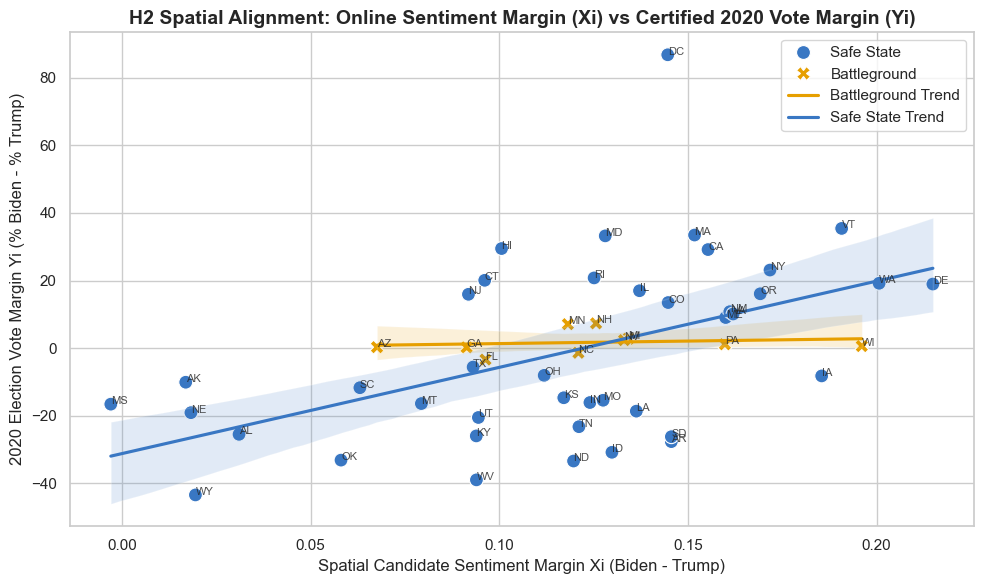

In [4]:
spatial_df = pd.read_parquet(P4_DATA_DIR / "spatial_state_matrix.parquet")
spatial_df["Group"] = spatial_df["historical_classification"].apply(lambda x: "Battleground" if x == "battleground" else "Safe State")

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=spatial_df,
    x="state_sentiment_margin_Xi",
    y="democratic_margin_pct_2020",
    hue="Group",
    style="Group",
    palette={"Battleground": "#E69F00", "Safe State": "#3977C3"},
    s=100
)
sns.regplot(data=spatial_df[spatial_df["Group"]=="Battleground"], x="state_sentiment_margin_Xi", y="democratic_margin_pct_2020", scatter=False, color="#E69F00", label="Battleground Trend")
sns.regplot(data=spatial_df[spatial_df["Group"]=="Safe State"], x="state_sentiment_margin_Xi", y="democratic_margin_pct_2020", scatter=False, color="#3977C3", label="Safe State Trend")

for idx, row in spatial_df.iterrows():
    plt.annotate(row["state_code"], (row["state_sentiment_margin_Xi"], row["democratic_margin_pct_2020"]), fontsize=8, alpha=0.8)

plt.title("H2 Spatial Alignment: Online Sentiment Margin (Xi) vs Certified 2020 Vote Margin (Yi)", fontsize=14, fontweight="bold")
plt.xlabel("Spatial Candidate Sentiment Margin Xi (Biden - Trump)", fontsize=12)
plt.ylabel("2020 Election Vote Margin Yi (% Biden - % Trump)", fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()